## ✅ Import Libraries

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## ✅Laoding and Preparing Training DataSet

In [2]:
# loading data
df = pd.read_csv("../data/processed/cleaned_news.csv")

In [3]:
df.head()

,content,label,char_length,word_length,clean_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,0,5180,889,law enforcement on high alert following threat...
1,Did they post their votes for Hillary already?,0,46,8,did they post their votes for hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,0,354,52,unbelievable obamas attorney general says most...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",1,8116,1337,bobby jindal raised hindu uses story of christ...
4,SATAN 2: Russia unvelis an image of its terrif...,0,2012,345,satan russia unvelis an image of its terrifyin...


In [4]:
# Check for missing values in the clean_content column
df["clean_content"].isnull().sum()

np.int64(48)

In [5]:
# Replace NaN values in clean_content with empty strings
df["clean_content"] = df["clean_content"].fillna("")

In [6]:
# checking for null values in the cleaned content column again
df["clean_content"].isnull().sum()

np.int64(0)

In [7]:
# splitting data into features and target variable
X = df["clean_content"]
y = df["label"]

In [8]:
# splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# vectorizing text data using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [10]:
# transforming training and testing data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## ✅Logistic Regression Model

In [11]:
# training a logistic regression model
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

# making predictions on the test set
y_pred_lr = lr_model.predict(X_test_tfidf)

Accuracy: 0.9599
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      5694
           1       0.96      0.96      0.96      7042

    accuracy                           0.96     12736
   macro avg       0.96      0.96      0.96     12736
weighted avg       0.96      0.96      0.96     12736



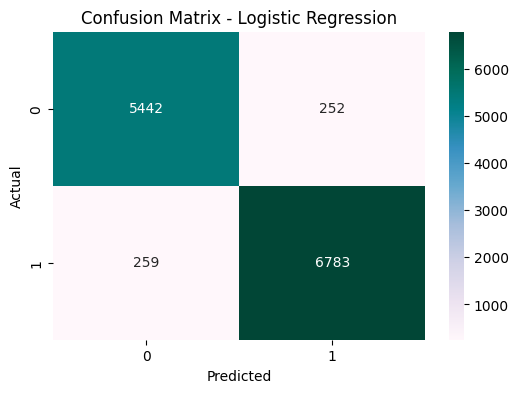

In [12]:
# evaluating the logistic regression model
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="PuBuGn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## ✅ Random Forest Model

In [13]:
# training a random forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# making predictions on the test set
y_pred_rf = rf_model.predict(X_test_tfidf)

Accuracy: 0.9544
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5694
           1       0.96      0.96      0.96      7042

    accuracy                           0.95     12736
   macro avg       0.95      0.95      0.95     12736
weighted avg       0.95      0.95      0.95     12736

Confusion Matrix:
[[5400  294]
 [ 287 6755]]


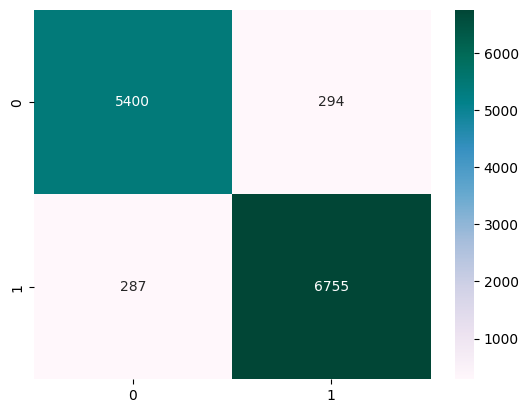

In [ ]:
# evaluating the random forest model
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="PuBuGn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## ✅ XGBoost Model

In [ ]:
# training the XGBoost model
# We use 'binary:logistic' for binary classification (Real/Fake)
xgb_model = XGBClassifier(
    n_estimators=100,
    objective='binary:logistic',
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
# fitting the XGBoost model
xgb_model.fit(X_train_tfidf, y_train)

# making predictions
y_pred_xgb = xgb_model.predict(X_test_tfidf)

/home/home/.pyenv/versions/3.10.13/envs/Fatocheck/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:08:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9633
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5694
           1       0.97      0.96      0.97      7042

    accuracy                           0.96     12736
   macro avg       0.96      0.96      0.96     12736
weighted avg       0.96      0.96      0.96     12736

Confusion Matrix:


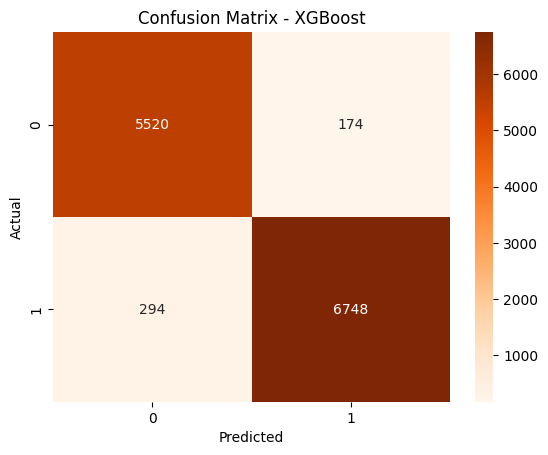

In [29]:
# evaluating the XGBoost model
accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

## ✅ Feature Importance

### Random Forest

/tmp/ipykernel_614669/4028098193.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20), palette="plasma")


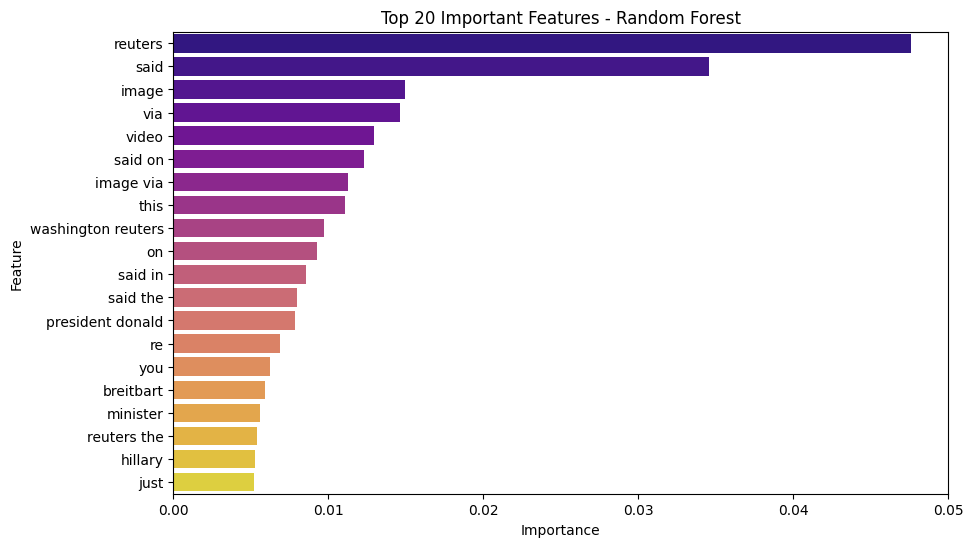

In [19]:
# feature importance from random forest
feature_importances = rf_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

# visualizing top 20 important features
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20), palette="plasma")
plt.title("Top 20 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Logistic Regression

/tmp/ipykernel_614669/3002562915.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20), palette="plasma")


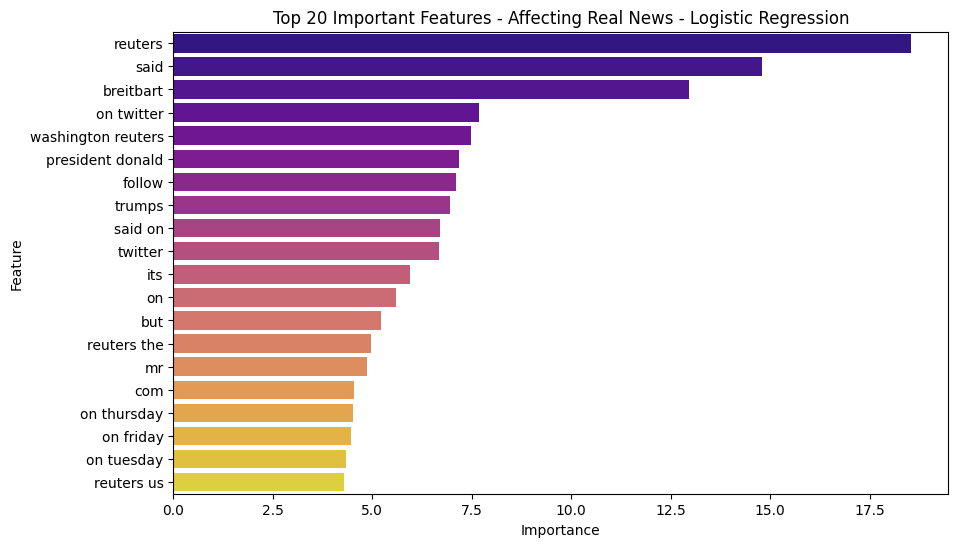

In [22]:
# feature importance from logistic regression
feature_importances = lr_model.coef_[0]
feature_names = vectorizer.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

# visualizing top 20 important features
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20), palette="plasma")
plt.title("Top 20 Important Features - Affecting Real News - Logistic Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

/tmp/ipykernel_614669/2549314231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=fake_indicators, palette="cividis")


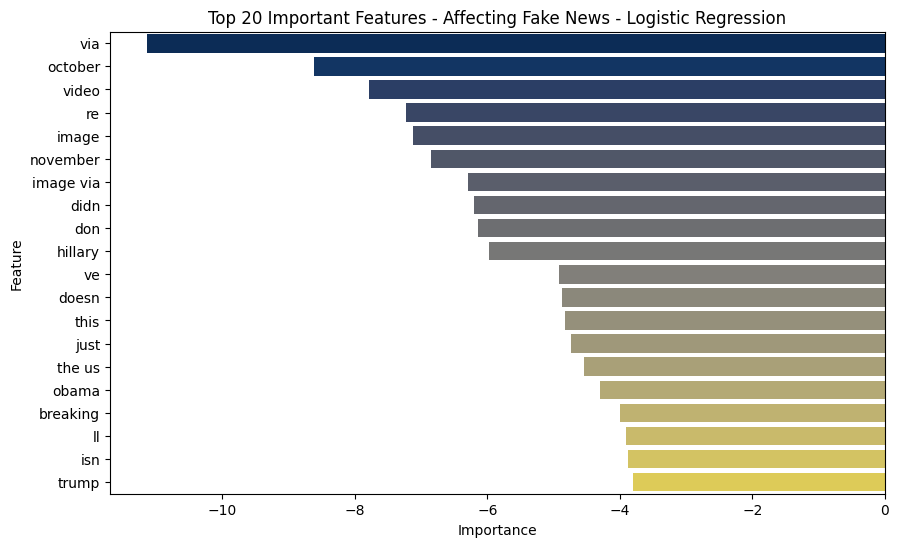

In [21]:
# To specifically find features that indicate Fake News (Class 0):
fake_indicators = feature_importance_df.sort_values(by="importance", ascending=True).head(20)

# visualizing top 20 important features for fake news indicators
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=fake_indicators, palette="cividis")
plt.title("Top 20 Important Features - Affecting Fake News - Logistic Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### XGBoost

/tmp/ipykernel_614669/1643699606.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20), palette="plasma")


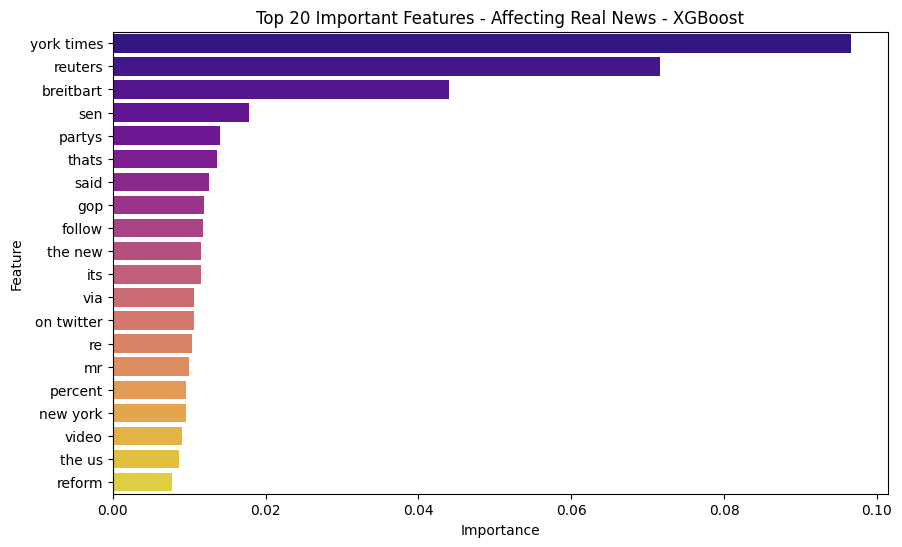

In [ ]:
# feature importance from XGBoost
feature_importances = xgb_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

# visualizing top 20 important features
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20), palette="plasma")
plt.title("Top 20 Most Predictive Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## ✅ Baseline Training Summary

### Key Findings:
- #### Three baseline models were evaluated: Logistic Regression, Random Forest and XGBoost.
- #### All of the models performed exceptionally well, achieving balanced F1-scores of 0.96, and 0.95 and 0.96 respectively, indicating no classification bias towards fake or real news.
- #### Logistic Regression achieved a slightly higher overall accuracy (95.99%) compared to Random Forest (95.44%).
- #### Pipeline Optimization: Discovered that 48 extremely short articles collapse into empty strings during text preprocessing, resulting in `NaN` parsing when reloading files via Pandas; adding a `.fillna("")` step stabilizes vectorizer entry.
- #### Feature importance extraction revealed distinctive language patterns, with strong political bigrams and structural phrasing acting as primary separators between the two target classes.